<a href="https://colab.research.google.com/github/fadeeva/nakedML/blob/master/MLnotes/003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

from scipy import stats

import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('ggplot')

In [2]:
import kagglehub

path = kagglehub.dataset_download("kumarajarshi/life-expectancy-who")
print("Path to dataset files:", path)

100%|██████████| 119k/119k [00:00<00:00, 42.6MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/kumarajarshi/life-expectancy-who/versions/1


In [3]:
rng = np.random.default_rng()

In [31]:
df = pd.read_csv(f'{path}/Life Expectancy Data.csv')
df.drop('Status', inplace=True, axis=1)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
df.columns = [col.strip().lower() for col in df.columns]
df.head()

,country,year,life expectancy,adult mortality,infant deaths,alcohol,percentage expenditure,hepatitis b,measles,bmi,...,polio,total expenditure,diphtheria,hiv/aids,gdp,population,thinness 1-19 years,thinness 5-9 years,income composition of resources,schooling
0,Afghanistan,2015,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


# /03
## Outliers Detection
### Find Symmetrical Samples

$$
|h_p - \overline{p}| \le 3\sqrt\frac{s^2_p}{n}
$$

In [39]:
features = [
    'schooling',
    'hiv/aids',
    'diphtheria',
    'total expenditure',
    'hepatitis b',
    'polio'
]

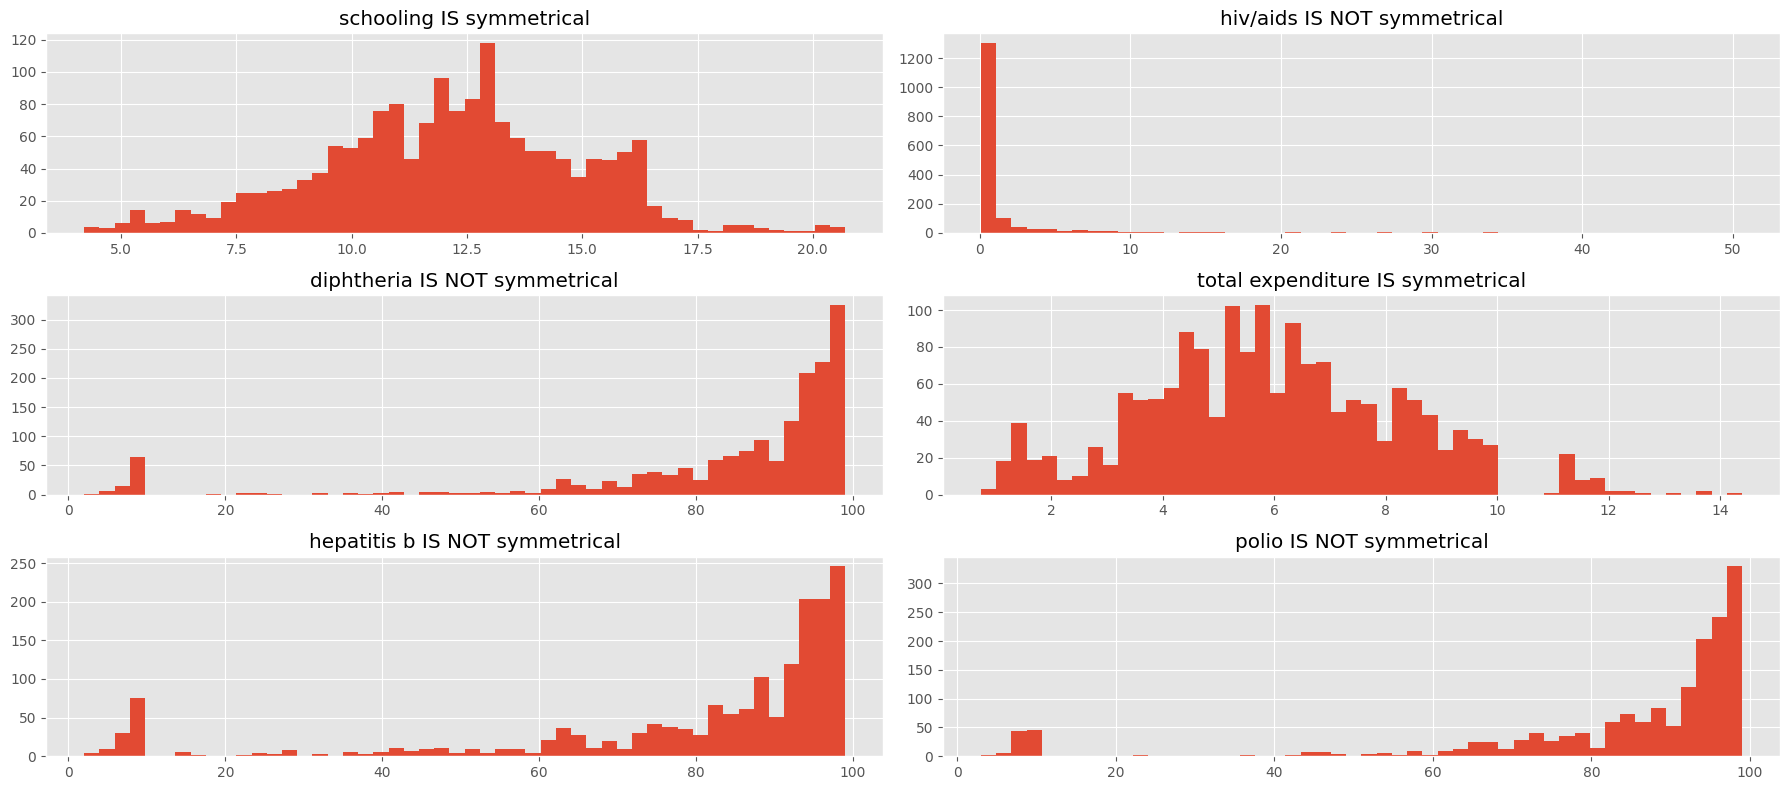

In [40]:
is_symmetrical = lambda f: np.abs(f.median() - f.mean()) <= 3 * np.sqrt(f.std()**2 / len(f))

fig, axs = plt.subplots(3, 2, figsize=(18, 8))
axs = axs.flatten()

for i, f in enumerate(features):
    axs[i].hist(df[f], bins=50)
    axs[i].set_title(f'{f} {'IS' if is_symmetrical(df[f]) else 'IS NOT'} symmetrical')

plt.tight_layout()